<a href="https://colab.research.google.com/github/Surhan-Memon/wine_fraud_using_SVM/blob/main/wine_fraud_using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('/content/wine_fraud.csv')

In [19]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [20]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

In [21]:
df['quality'].value_counts()

,count
quality,
Legit,6251
Fraud,246


<Axes: xlabel='quality', ylabel='count'>

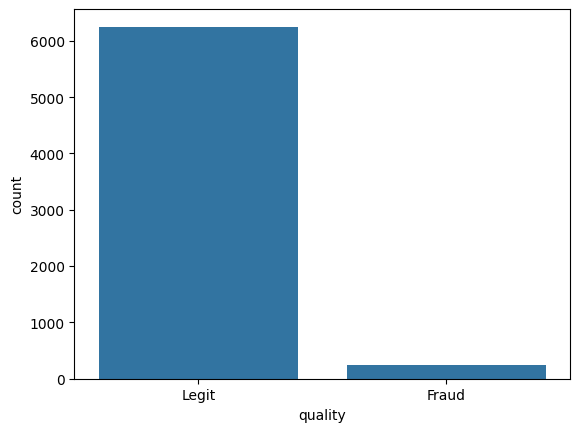

In [22]:
sns.countplot(x='quality',data=df)

<Axes: xlabel='type', ylabel='count'>

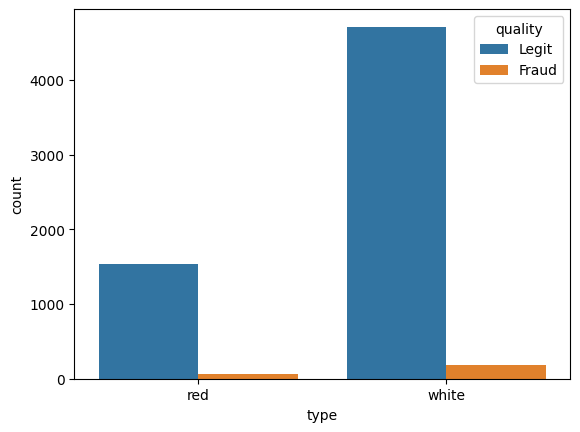

In [23]:
sns.countplot(hue='quality',data=df, x='type')

In [24]:
reds = df[df['type']=='red']

In [25]:
whites = df[df['type']=='white']

In [26]:
100*len(reds[reds['quality']=='Fraud'])/len(reds)

3.9399624765478425

In [27]:
100*len(whites[whites['quality']=='Fraud'])/len(whites)

3.736218864842793

In [32]:
df['Fraud'] = df['quality'].map({'Legit':0, 'Fraud':1})

<Axes: >

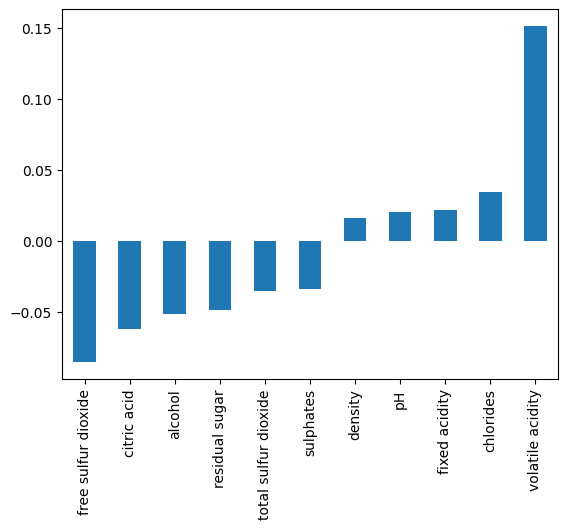

In [36]:
df.corr(numeric_only=True)['Fraud'][:-1].sort_values().plot(kind='bar')

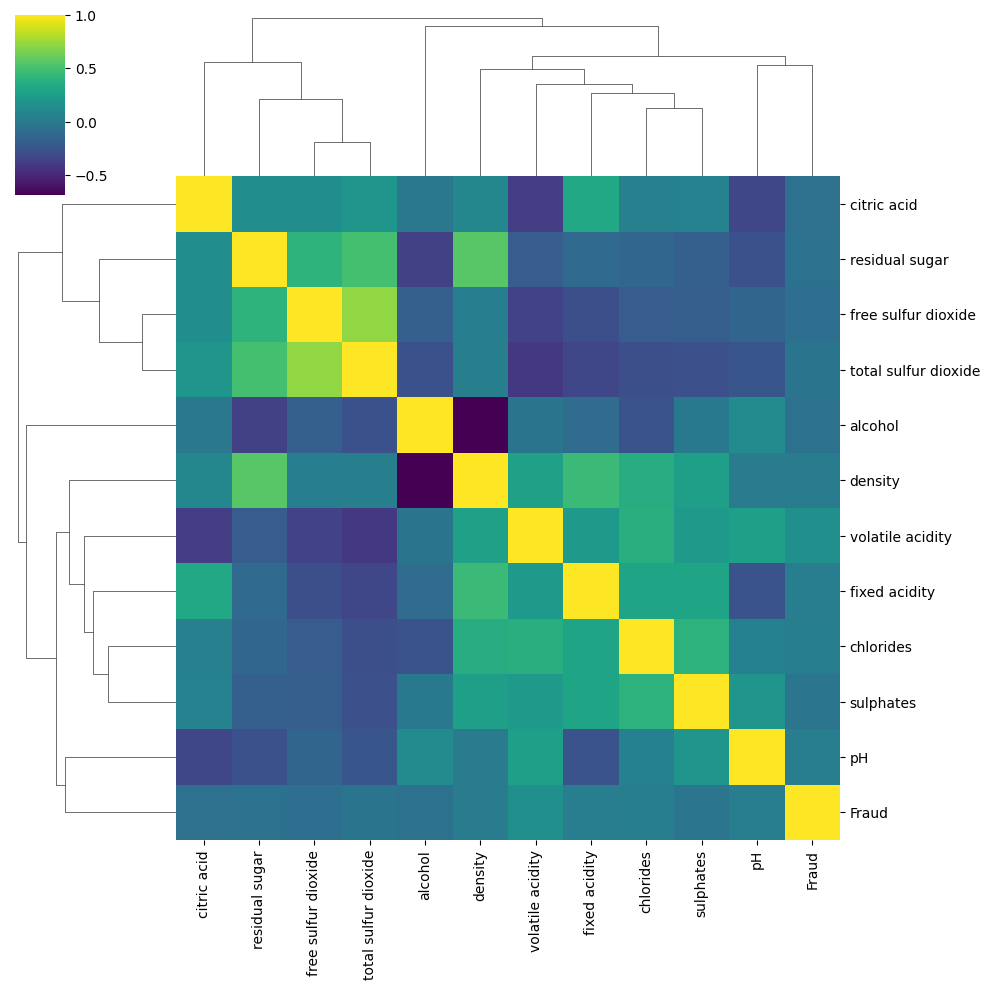

In [38]:
sns.clustermap(df.corr(numeric_only=True),cmap='viridis')

In [44]:
df['type'] = pd.get_dummies(df['type'], drop_first=True)

In [45]:
X = df.drop('quality', axis=1)

In [46]:
y = df['quality']

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
scaler = StandardScaler()

In [51]:
scaled_X_train = scaler.fit_transform(X_train)

In [52]:
scaled_X_test = scaler.transform(X_test)

In [55]:
from sklearn.svm import SVC

In [56]:
svc = SVC(class_weight='balanced')

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1]}

In [59]:
grid = GridSearchCV(svc, param_grid)

In [60]:
grid.fit(scaled_X_train, y_train)

GridSearchCV(estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1]})

In [61]:
grid.best_params_

{'C': 1}

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [63]:
grid_preds = grid.predict(scaled_X_test)

In [65]:
cm = confusion_matrix(y_test, grid_preds)
cm

array([[ 17,  10],
       [ 92, 531]])

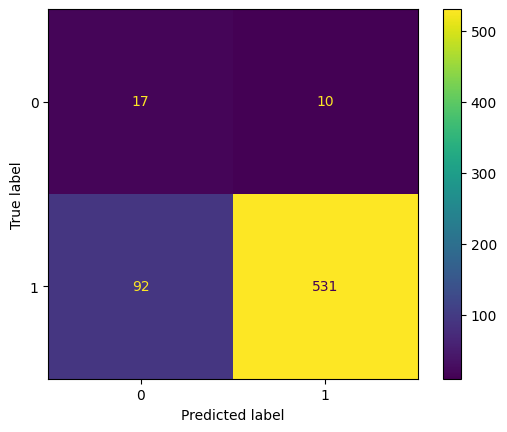

In [66]:
ConfusionMatrixDisplay(cm).plot()

In [67]:
print(classification_report(y_test, grid_preds))

              precision    recall  f1-score   support

       Fraud       0.16      0.63      0.25        27
       Legit       0.98      0.85      0.91       623

    accuracy                           0.84       650
   macro avg       0.57      0.74      0.58       650
weighted avg       0.95      0.84      0.88       650

